# Module 4 — Market Data Acquisition

## Objectives
- Download historical daily price data for the 9-asset universe via yFinance
- Validate that all tickers returned complete data
- Save raw data locally for reproducibility

## Business Context
Every downstream calculation (returns, risk, optimization) depends on this data.
The acquisition pipeline must be reusable, not a one-off script, since the
Streamlit app and backtester will also need to refresh this data later.

## Data Requirements
- Universe: SPY, QQQ, VEA, VWO, IEF, TLT, SHY, VNQ, GLD
- Period: 2008-01-01 to present (rationale: VEA's July 2007 inception is the
  binding constraint on how far back all 9 assets can share a common history)
- Frequency: Daily
- Adjustment: auto_adjust=True (splits/dividends adjusted)

In [1]:
import sys
sys.path.append("..")  # add project root so we can import from src/

from src.data.loader import download_asset_data, TICKERS, START_DATE, END_DATE

print(f"Universe: {TICKERS}")
print(f"Period: {START_DATE} to {END_DATE}")

Universe: ['SPY', 'QQQ', 'VEA', 'VWO', 'IEF', 'TLT', 'SHY', 'VNQ', 'GLD']
Period: 2008-01-01 to 2026-09-27


In [2]:
prices, volumes = download_asset_data(TICKERS, START_DATE, END_DATE)
prices.tail()

Date range: 2008-01-01 to 2026-09-27


[*********************100%***********************]  9 of 9 completed


Successfully downloaded data: 4713 rows, 9 tickers
Date range returned: 2008-01-02 to 2026-09-25


,SPY,QQQ,VEA,VWO,IEF,TLT,SHY,VNQ,GLD
Date,,,,,,,,,
2026-09-21,773.500000,741.469971,72.300003,61.139999,91.150002,81.800003,81.290001,93.003365,398.380005
2026-09-22,773.380005,747.460022,72.709999,61.099998,91.160004,81.750000,81.320000,92.815002,400.070007
2026-09-23,767.809998,741.210022,71.419998,60.119999,90.190002,80.459999,81.120003,91.449997,392.880005
2026-09-24,767.179993,741.099976,71.050003,59.869999,89.690002,79.419998,81.089996,91.169998,391.690002
2026-09-25,771.349976,744.500000,71.839996,60.160000,90.000000,79.320000,81.209999,90.989998,393.410004


In [3]:
prices.info()
prices.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 4713 entries, 2008-01-02 to 2026-09-25
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPY     4713 non-null   float64
 1   QQQ     4713 non-null   float64
 2   VEA     4713 non-null   float64
 3   VWO     4713 non-null   float64
 4   IEF     4713 non-null   float64
 5   TLT     4713 non-null   float64
 6   SHY     4713 non-null   float64
 7   VNQ     4713 non-null   float64
 8   GLD     4713 non-null   float64
dtypes: float64(9)
memory usage: 368.2 KB


,SPY,QQQ,VEA,VWO,IEF,TLT,SHY,VNQ,GLD
count,4713.000000,4713.000000,4713.000000,4713.000000,4713.000000,4713.000000,4713.000000,4713.000000,4713.000000
mean,264.190651,200.728186,32.984325,33.482368,82.233276,87.192422,70.312148,55.785154,160.319822
std,179.674483,177.402026,12.201315,8.921118,11.849821,20.139119,4.560909,22.153649,74.304966
min,49.557529,21.983988,11.551431,11.178647,55.201607,51.212475,60.814472,10.363996,70.000000
25%,110.282463,58.730869,24.223631,27.842817,76.328583,76.459724,67.504768,37.251320,117.790001
50%,206.183853,129.179459,29.692272,31.397121,83.859589,85.761330,69.027313,56.650429,136.880005
75%,386.225433,309.779816,40.417789,37.397697,89.395172,96.396011,73.606491,73.243034,172.339996
max,775.953186,747.460022,73.607956,61.323086,104.941353,141.584473,81.835434,100.081970,495.899994


In [4]:
from src.data.loader import save_raw_data

save_raw_data(prices, volumes, TICKERS, START_DATE, END_DATE)

Saved price data to: C:\Users\pc\Documents\projects\Portfolio_Construction_Platform\data\raw\asset_prices.csv
Saved volume data to: C:\Users\pc\Documents\projects\Portfolio_Construction_Platform\data\raw\asset_volumes.csv
Saved metadata to: C:\Users\pc\Documents\projects\Portfolio_Construction_Platform\data\raw\asset_prices_metadata.json


# Module 5 — Data Validation & Quality

## Objectives
- Verify the downloaded price and volume data is structurally correct and free of hidden data-quality issues
- Check for missing observations, duplicate dates, unexpected gaps, suspicious price values, and volume anomalies
- Produce a reusable, automated Data Quality Report rather than relying on manual eyeballing

## Business Context
Every downstream calculation — returns, risk, correlations, optimization — inherits
whatever errors exist in the raw data. A single bad data point can silently distort
a covariance matrix enough to produce a nonsensical "optimal" portfolio. This module
formalizes the trust check that a professional data pipeline never skips.

## Quantitative Concepts
- Survivorship bias, look-ahead bias, and data leakage (why they matter, even though
  our fixed 9-ETF universe is not directly exposed to survivorship bias)
- Corporate actions and adjusted prices (revisited here as a validation concern,
  not just an acquisition-time setting)

## Data Requirements
- Inputs: `prices` and `volumes` DataFrames from Module 4 (9 tickers, 2008-01-02 to present)

## Implementation
Validation logic lives in `src/data/validation.py` as reusable, independent check
functions, aggregated by `run_all_checks()` into a single Data Quality Report.

In [5]:
import sys
sys.path.append("..")
from src.data.validation import run_all_checks

report = run_all_checks(prices, volumes, TICKERS)

DATA QUALITY REPORT
[PASS] dimensions
[PASS] duplicate_dates
[PASS] missing_values
[PASS] date_continuity
[PASS] suspicious_values
[PASS] volume_anomalies
Overall: ALL CHECKS PASSED


## The 2 below cells are for checking the NaN on the most recent days

In [6]:
report["results"]["missing_values"]

{'check': 'missing_values',
 'passed': True,
 'nan_counts_by_ticker': {},
 'total_nans': 0}

In [7]:
# Find which date(s) have NaNs, and for which tickers
nan_rows = prices[prices.isna().any(axis=1)]
nan_rows

,SPY,QQQ,VEA,VWO,IEF,TLT,SHY,VNQ,GLD
Date,,,,,,,,,


# Module 6 — Return Engine

## Objectives
- Convert validated price data into simple returns, log returns, cumulative
  returns, and annualized returns
- Understand why returns (not prices) are the correct input for all
  downstream risk, correlation, and optimization calculations
- Build a reusable, well-documented return calculation module

## Business Context
Prices are not comparable across assets and are not statistically well-behaved
for the calculations ahead (volatility, correlation, optimization). Returns are
the actual unit of analysis for every module from here on — this is the
translation layer between "raw market data" and "portfolio theory."

## Quantitative Concepts
- Simple returns vs. log returns: what each represents, and why log returns
  are time-additive while simple returns must be compounded, not summed
- Cumulative return: total growth of an investment over a period
- Annualized return: converting a multi-day return into a standardized
  yearly-equivalent figure, using the 252-trading-day convention

## Data Requirements
- Input: `prices` DataFrame from Module 4/5 (validated, 9 tickers, 2008-01-02
  to present, no missing values)

## Implementation
Return calculation logic lives in `src/features/return_calculator.py` as four
independent, reusable functions: `calculate_simple_returns`,
`calculate_log_returns`, `calculate_cumulative_returns`, and
`calculate_annualized_return`.

In [8]:
import sys
sys.path.append("..")
from src.features.return_calculator import (
    calculate_simple_returns, calculate_log_returns,
    calculate_cumulative_returns, calculate_annualized_return
)

simple_returns = calculate_simple_returns(prices)
log_returns = calculate_log_returns(prices)
cumulative_returns = calculate_cumulative_returns(simple_returns)
annualized_returns = calculate_annualized_return(simple_returns)

print(simple_returns.head())
print(annualized_returns)

                 SPY       QQQ       VEA       VWO       IEF       TLT  \
Date                                                                     
2008-01-03 -0.000483  0.004166  0.001673  0.009615  0.002054 -0.001377   
2008-01-04 -0.024507 -0.043856 -0.021925 -0.033047  0.002620  0.000212   
2008-01-07 -0.000849 -0.004752  0.001281  0.007879  0.001817  0.004350   
2008-01-08 -0.016148 -0.025950 -0.008102 -0.000781  0.002155 -0.001161   
2008-01-09  0.010510  0.021313  0.006449  0.024254 -0.001584  0.001904   

                 SHY       VNQ       GLD  
Date                                      
2008-01-03  0.001579 -0.031173  0.008367  
2008-01-04  0.001456 -0.040599 -0.005142  
2008-01-07 -0.000606  0.009306 -0.004229  
2008-01-08  0.001454 -0.034621  0.023711  
2008-01-09 -0.000484  0.017661 -0.002650  
SPY    0.113704
QQQ    0.164361
VEA    0.052845
VWO    0.035646
IEF    0.026312
TLT    0.021405
SHY    0.015587
VNQ    0.064540
GLD    0.085489
dtype: float64


# Module 7 — Exploratory Market Analysis

## Objectives
- Visually explore the price, return, correlation, and volatility behavior
  of the asset universe before formal portfolio theory is introduced
- Confirm patterns expected from finance theory (volatility clustering,
  rising correlations in crises, fat-tailed return distributions) actually
  appear in our own data
- Produce a saved, reusable set of figures for later use in the README and
  research report

## Business Context
Numbers in a table can hide patterns that are immediately obvious in a
chart. This module builds the visual intuition that later modules
(risk, optimization, stress testing) will formalize mathematically.

## Data Requirements
- `prices` and `simple_returns` from Modules 4–6

## Implementation
Plotting logic lives in `src/utils/visualization.py` as reusable functions
that both display inline and save to `figures/`, so they can be reused
throughout the rest of the project.

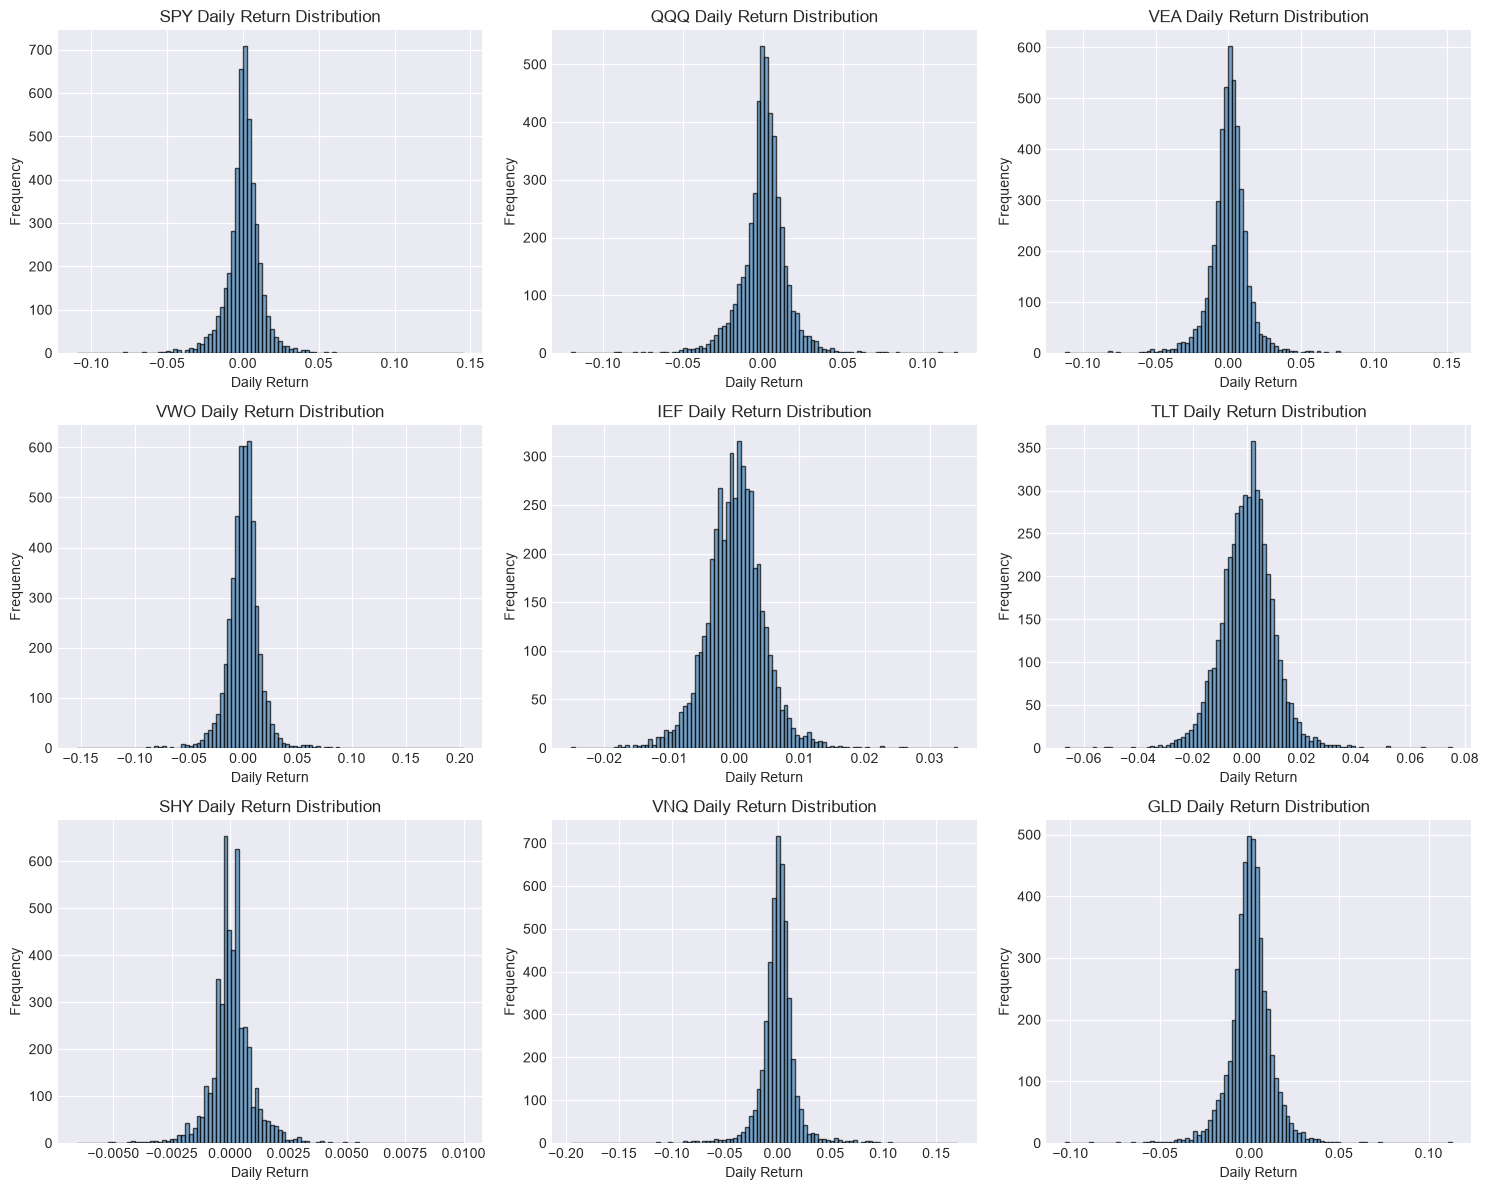

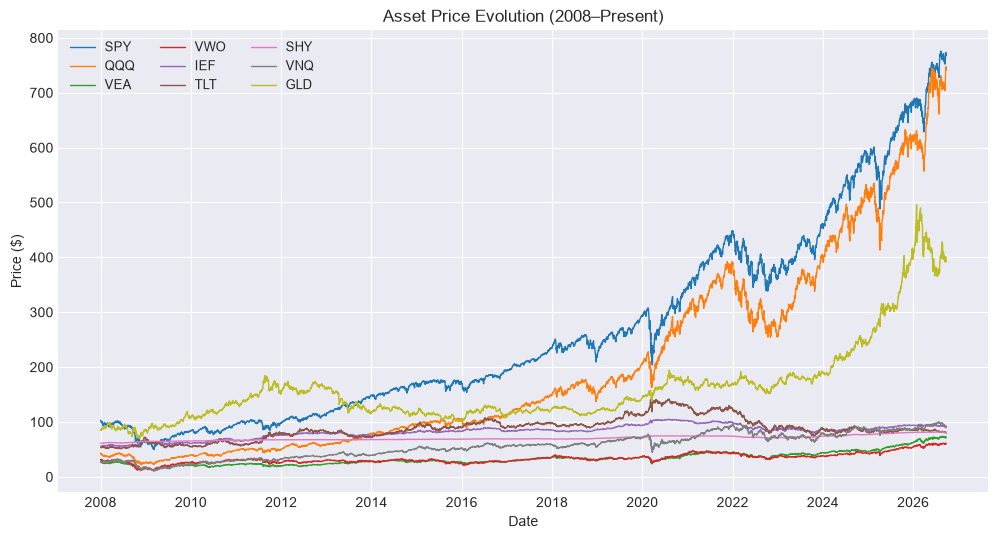

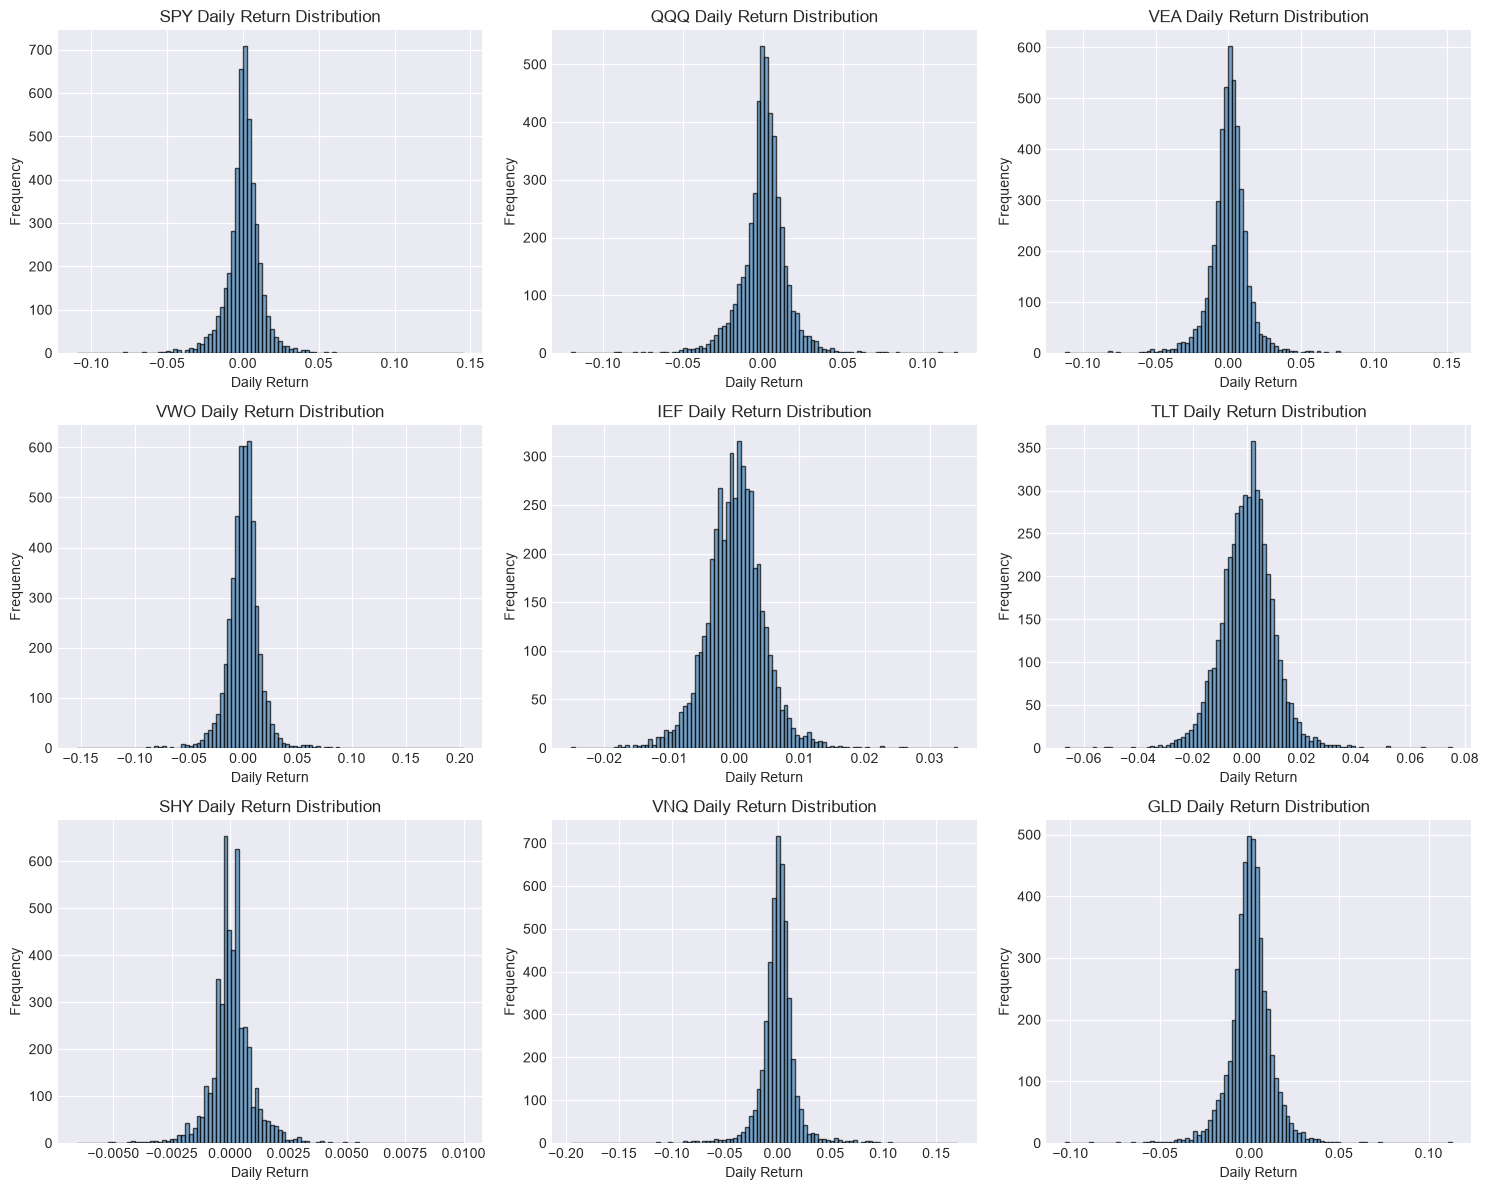

In [9]:
import sys
sys.path.append("..")
from src.utils.visualization import plot_price_evolution, plot_return_distributions

plot_price_evolution(prices)
plot_return_distributions(simple_returns)

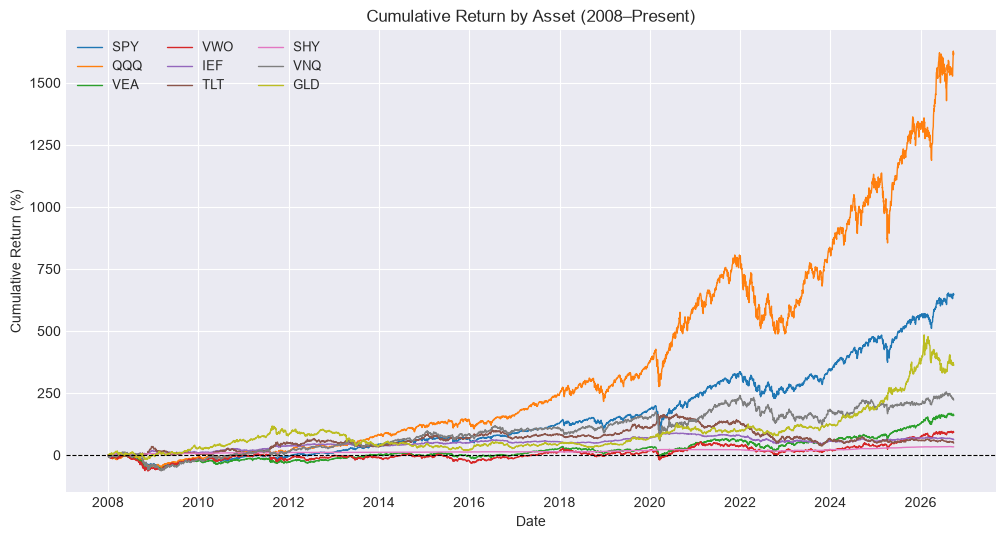

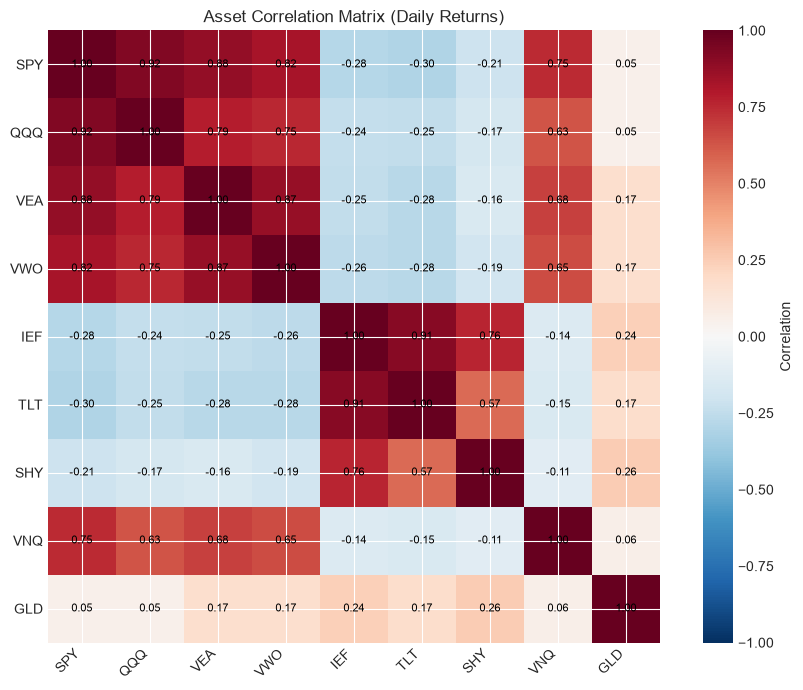

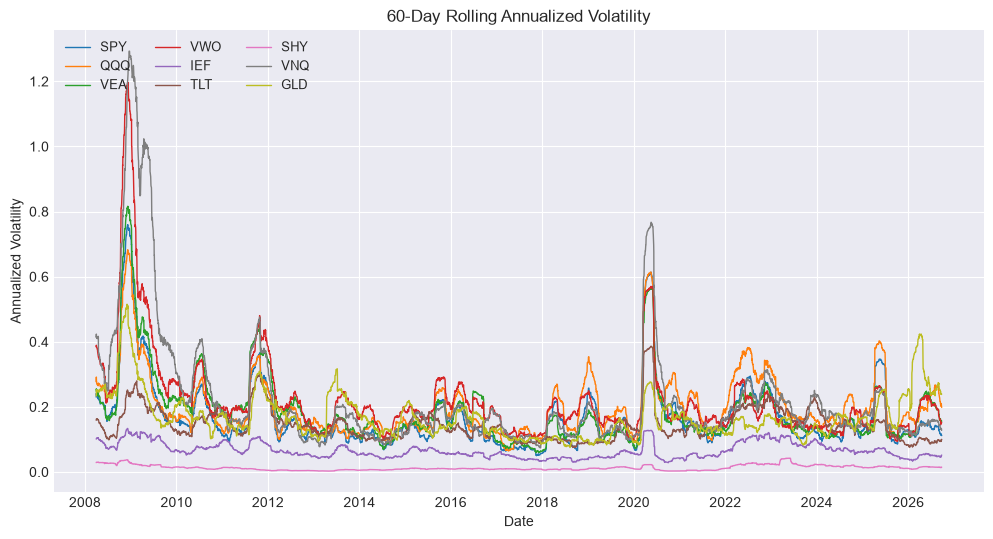

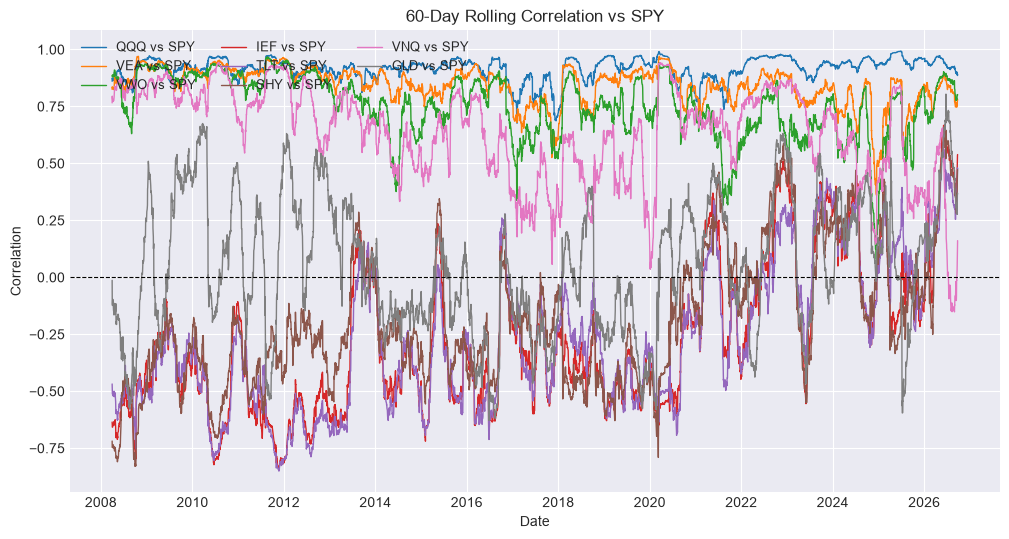

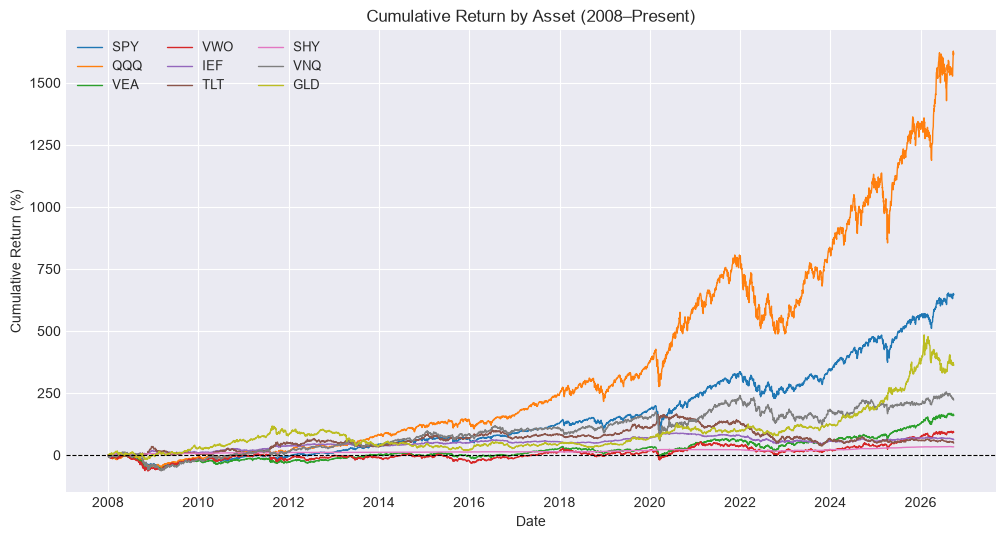

In [10]:
from src.utils.visualization import (
    plot_correlation_heatmap, plot_rolling_volatility,
    plot_rolling_correlation, plot_cumulative_performance
)
plot_correlation_heatmap(simple_returns)
plot_rolling_volatility(simple_returns, window=60)
plot_rolling_correlation(simple_returns, benchmark="SPY", window=60)
plot_cumulative_performance(cumulative_returns)

# Module 8 — Portfolio Theory

## Objectives
- Implement core Modern Portfolio Theory formulas from scratch using NumPy:
  expected return, variance, volatility, and Sharpe ratio
- Understand the matrix form of portfolio variance and why it mathematically
  captures diversification benefit
- Compute these metrics for a first, simple equal-weight portfolio as a
  baseline before any optimization is introduced

## Business Context
This module is the mathematical foundation for every later portfolio
construction and optimization decision. Understanding these formulas from
first principles (rather than trusting a library black box) is what
distinguishes genuine quantitative competence from tool usage.

## Quantitative Concepts
- Portfolio expected return as a weighted average
- Variance, covariance, and correlation
- Portfolio variance in matrix form: w^T . Sigma . w, and why the covariance
  cross-terms are the mathematical source of diversification benefit
- The efficient frontier (conceptual introduction; formal construction in
  Module 12)
- Risk-free rate and the Sharpe ratio

## Data Requirements
- `simple_returns` and `annualized_returns` from Module 6

## Implementation
Core formulas live in `src/portfolio/portfolio_theory.py`, tested here
against a simple equal-weight portfolio as a baseline.

In [11]:
import sys
sys.path.append("..")
import numpy as np
from src.portfolio.portfolio_theory import (
    portfolio_expected_return, portfolio_variance, portfolio_volatility,
    sharpe_ratio, calculate_annualized_covariance_matrix
)

n_assets = len(TICKERS)
equal_weights = np.array([1/n_assets] * n_assets)

cov_matrix = calculate_annualized_covariance_matrix(simple_returns)
exp_return = portfolio_expected_return(equal_weights, annualized_returns)
exp_vol = portfolio_volatility(equal_weights, cov_matrix)
exp_sharpe = sharpe_ratio(exp_return, exp_vol, risk_free_rate=0.02)

print(f"Equal-Weight Portfolio Expected Return: {exp_return:.2%}")
print(f"Equal-Weight Portfolio Volatility: {exp_vol:.2%}")
print(f"Equal-Weight Portfolio Sharpe Ratio: {exp_sharpe:.3f}")

Equal-Weight Portfolio Expected Return: 6.44%
Equal-Weight Portfolio Volatility: 11.97%
Equal-Weight Portfolio Sharpe Ratio: 0.371


In [12]:
# Compare: portfolio volatility vs. the naive weighted-average of individual volatilities
individual_vols = np.sqrt(np.diag(cov_matrix))  # each asset's own annualized volatility
naive_weighted_avg_vol = np.dot(equal_weights, individual_vols)

print(f"Naive weighted-average volatility (no diversification): {naive_weighted_avg_vol:.2%}")
print(f"Actual portfolio volatility (with diversification):     {exp_vol:.2%}")
print(f"Diversification benefit (reduction in volatility):      {naive_weighted_avg_vol - exp_vol:.2%}")

Naive weighted-average volatility (no diversification): 17.89%
Actual portfolio volatility (with diversification):     11.97%
Diversification benefit (reduction in volatility):      5.93%


# Module 9 — Portfolio Risk Engine

## Objectives
- Build a reusable risk analytics engine covering downside volatility,
  maximum drawdown, Historical and Parametric VaR, CVaR, tracking error,
  beta, and concentration risk (HHI)
- Understand the assumptions and limitations behind each risk measure,
  especially where Parametric VaR's normality assumption breaks down for
  fat-tailed assets identified in Module 7
- Apply the full risk suite to the equal-weight baseline portfolio from
  Module 8

## Business Context
Volatility alone is an incomplete risk picture — it treats upside and
downside symmetrically and says nothing about tail severity or benchmark-
relative risk. This module builds the fuller risk toolkit real portfolio
and risk managers actually use to evaluate whether a portfolio's risk
profile is acceptable.

## Quantitative Concepts
- Downside volatility (semi-deviation)
- Maximum drawdown
- Historical VaR vs. Parametric VaR, and why their assumptions differ
- CVaR (Expected Shortfall) as a more complete tail-risk measure than VaR alone
- Tracking error and beta relative to a benchmark (SPY)
- Herfindahl-Hirschman Index as a concentration-risk measure

## Data Requirements
- `simple_returns`, `equal_weights` from Module 8
- Benchmark: SPY

## Implementation
Risk functions live in `src/risk/risk_engine.py`, applied here to the
equal-weight portfolio's own return series (weights dotted with asset
returns).

In [13]:
import sys
sys.path.append("..")
import numpy as np
from src.risk.risk_engine import (
    downside_volatility, maximum_drawdown, historical_var, parametric_var,
    historical_cvar, tracking_error, beta, herfindahl_index
)
from src.features.return_calculator import calculate_cumulative_returns

# Build the equal-weight portfolio's own daily return series
portfolio_returns = simple_returns.dot(equal_weights)
portfolio_returns.name = "Equal-Weight Portfolio"
portfolio_cumulative = calculate_cumulative_returns(portfolio_returns)

# Run the full risk suite
print(f"Downside Volatility: {downside_volatility(portfolio_returns):.2%}")

mdd = maximum_drawdown(portfolio_cumulative)
print(f"Maximum Drawdown: {mdd['max_drawdown']:.2%} (peak: {mdd['peak_date']}, trough: {mdd['trough_date']})")

print(f"Historical VaR (95%): {historical_var(portfolio_returns, 0.95):.2%}")
print(f"Historical VaR (99%): {historical_var(portfolio_returns, 0.99):.2%}")
print(f"Parametric VaR (95%): {parametric_var(portfolio_returns, 0.95):.2%}")
print(f"Parametric VaR (99%): {parametric_var(portfolio_returns, 0.99):.2%}")

print(f"Historical CVaR (95%): {historical_cvar(portfolio_returns, 0.95):.2%}")
print(f"Historical CVaR (99%): {historical_cvar(portfolio_returns, 0.99):.2%}")

benchmark_returns = simple_returns["SPY"]
print(f"Tracking Error vs SPY: {tracking_error(portfolio_returns, benchmark_returns):.2%}")
print(f"Beta vs SPY: {beta(portfolio_returns, benchmark_returns):.3f}")

print(f"HHI (Concentration): {herfindahl_index(equal_weights):.4f}")

Downside Volatility: 8.34%
Maximum Drawdown: -33.87% (peak: 2008-05-19, trough: 2008-11-20)
Historical VaR (95%): 1.06%
Historical VaR (99%): 2.11%
Parametric VaR (95%): 1.21%
Parametric VaR (99%): 1.72%
Historical CVaR (95%): 1.78%
Historical CVaR (99%): 3.12%
Tracking Error vs SPY: 10.40%
Beta vs SPY: 0.545
HHI (Concentration): 0.1111


## Note on Parametric CVaR

We deliberately do not implement Parametric CVaR alongside Historical CVaR.
Parametric CVaR relies on the same normality assumption as Parametric VaR,
applied even further into the tail — precisely the region where Module 7's
histograms showed real returns (especially VNQ and VWO) deviate most from a
normal distribution. Rather than report a tail-risk number built on an
assumption we already know breaks down hardest in the tail, we rely on
Historical CVaR, which reads the actual empirical tail directly from the data.

# Module 10 — Performance Analytics

## Objectives
- Compute CAGR, Sortino Ratio, Calmar Ratio, and Information Ratio for the
  equal-weight baseline portfolio
- Understand how each metric combines return with a different risk
  perspective from Module 9 (total volatility, downside volatility, max
  drawdown, tracking error)

## Business Context
Return alone is meaningless without knowing what risk was taken to achieve
it. This module builds the standard risk-adjusted performance metrics used
throughout the investment industry to evaluate whether a portfolio's return
was actually "worth" its risk.

## Note on Benchmark Choice
SPY is used here as the benchmark for Information Ratio, for consistency
with Modules 7–9. This is a preliminary choice for continuity, not a claim
that SPY is the ideal benchmark for a diversified 9-asset portfolio —
Module 15 (Benchmarking) will introduce more appropriate multi-asset
comparison points.

## Quantitative Concepts
- CAGR as the standard investment-industry growth metric
- Sortino Ratio: Sharpe Ratio's downside-risk-only counterpart
- Calmar Ratio: return relative to worst historical drawdown
- Information Ratio: benchmark-relative risk-adjusted return

## Data Requirements
- `portfolio_cumulative`, `portfolio_returns`, `exp_return` from Modules 8–9
- Risk engine outputs: `downside_volatility`, `maximum_drawdown`,
  `tracking_error` from Module 9

## Implementation
Performance ratio functions live in `src/performance/performance_analytics.py`,
combining Module 9's risk engine outputs with return data.

In [14]:
import sys
sys.path.append("..")
from src.performance.performance_analytics import (
    calculate_cagr, sortino_ratio, calmar_ratio, information_ratio
)

cagr = calculate_cagr(portfolio_cumulative)
print(f"CAGR: {cagr:.2%}")

d_vol = downside_volatility(portfolio_returns)
sortino = sortino_ratio(exp_return, d_vol, risk_free_rate=0.02)
print(f"Sortino Ratio: {sortino:.3f}")

calmar = calmar_ratio(exp_return, mdd["max_drawdown"])
print(f"Calmar Ratio: {calmar:.3f}")

benchmark_annualized_return = annualized_returns["SPY"]
te = tracking_error(portfolio_returns, benchmark_returns)
ir = information_ratio(exp_return, benchmark_annualized_return, te)
print(f"Information Ratio vs SPY: {ir:.3f}")

CAGR: 7.66%
Sortino Ratio: 0.533
Calmar Ratio: 0.190
Information Ratio vs SPY: -0.474


# Module 11 — Portfolio Construction

## Objectives
- Implement three distinct portfolio construction strategies: Equal Weight,
  Custom Allocation, and Inverse Volatility (risk-based) weighting
- Understand the tradeoffs each strategy makes — simplicity vs. data-driven
  weighting vs. subjective judgment — and what each one ignores
- Establish a consistent function interface (weights as a pd.Series indexed
  by ticker) so strategies can be compared directly in later modules

## Business Context
There is no single "correct" way to construct a portfolio. Different
construction philosophies exist because they make different tradeoffs
between simplicity, reliance on estimated data, and the ability to encode
investor judgment or strategic intent. Understanding these tradeoffs is a
prerequisite for choosing (or defending) a construction method in practice.

## Quantitative Concepts
- Equal weighting: no reliance on estimated data, but ignores risk/return/
  correlation entirely (as established in Modules 8–10)
- Custom allocation: encodes strategic/qualitative judgment, but is
  inherently subjective with no single "correct" version
- Inverse volatility weighting: uses actual computed risk data to reduce
  each asset's risk contribution, but ignores correlation structure
  entirely — a real gap given how much of Module 8's diversification
  benefit came specifically from covariance, not standalone volatility
- Optimization-based allocation (Minimum Variance, Maximum Sharpe) is
  intentionally deferred to Module 12, where the full covariance-aware
  machinery is built

## Data Requirements
- `TICKERS` from Module 4
- `simple_returns` from Module 6 (for inverse volatility weighting)
- A manually specified custom allocation dictionary (documented rationale
  in the notebook, not treated as a mathematically derived answer)

## Implementation
Construction strategies live in `src/portfolio/construction.py` as three
independent functions, each returning a `pd.Series` of weights indexed by
ticker, enabling direct comparison in Module 14.

In [15]:
from src.portfolio.construction import (
    equal_weight_portfolio, custom_allocation_portfolio, inverse_volatility_portfolio
)

custom_weights_dict = {
    "SPY": 0.20, "QQQ": 0.15, "VEA": 0.12, "VWO": 0.08,
    "IEF": 0.15, "TLT": 0.08, "SHY": 0.07,
    "VNQ": 0.08, "GLD": 0.07
}

eq_weights = equal_weight_portfolio(TICKERS)
custom_weights = custom_allocation_portfolio(custom_weights_dict)
inv_vol_weights = inverse_volatility_portfolio(simple_returns)

print("Equal Weight:\n", eq_weights)
print("\nCustom Allocation:\n", custom_weights)
print("\nInverse Volatility:\n", inv_vol_weights)

Equal Weight:
 SPY    0.111111
QQQ    0.111111
VEA    0.111111
VWO    0.111111
IEF    0.111111
TLT    0.111111
SHY    0.111111
VNQ    0.111111
GLD    0.111111
dtype: float64

Custom Allocation:
 SPY    0.20
QQQ    0.15
VEA    0.12
VWO    0.08
IEF    0.15
TLT    0.08
SHY    0.07
VNQ    0.08
GLD    0.07
dtype: float64

Inverse Volatility:
 SPY    0.044158
QQQ    0.038901
VEA    0.040540
VWO    0.033484
IEF    0.125101
TLT    0.057147
SHY    0.583254
VNQ    0.029532
GLD    0.047882
dtype: float64


##"""
Mean-variance optimization module.
Implements Minimum Variance Portfolio, Maximum Sharpe Portfolio, and
Efficient Frontier construction using scipy.optimize.
"""

In [16]:
import sys
sys.path.append("..")
from src.optimization.mean_variance import minimum_variance_portfolio

import pandas as pd

pd.set_option('display.float_format', '{:.20f}'.format)

min_var_weights = minimum_variance_portfolio(cov_matrix)
print(min_var_weights)
print(f'The total weights is: {min_var_weights.sum()}')

SPY   0.01026889302413698871
QQQ   0.00136718469798704795
VEA   0.00000000000000000000
VWO   0.00828538113497358925
IEF   0.00000000000000000000
TLT   0.00000000000000000397
SHY   0.98007854114290260394
VNQ   0.00000000000000000000
GLD   0.00000000000000000000
dtype: float64
The total weights is: 1.0000000000000002


In [17]:
from src.optimization.mean_variance import maximum_sharpe_portfolio

max_sharpe_weights = maximum_sharpe_portfolio(annualized_returns, cov_matrix, risk_free_rate=0.02)
print(max_sharpe_weights)

SPY   0.00000000000000000000
QQQ   0.41771236297482466915
VEA   0.00000000000000000000
VWO   0.00000000000000049185
IEF   0.36680810410769287833
TLT   0.00000000000000581452
SHY   0.00000000000000000000
VNQ   0.00000000000000012991
GLD   0.21547953291747679039
dtype: float64


In [18]:
from src.optimization.mean_variance import build_efficient_frontier

frontier = build_efficient_frontier(annualized_returns, cov_matrix, n_points=50)
frontier[["target_return", "volatility"]].head(10)

,target_return,volatility
0,0.01558735487635520833,0.01493922369254767520
1,0.01862356024156648637,0.01454779686985820455
2,0.02165976560677776441,0.01624086445127737727
3,0.02469597097198904592,0.01767040164935352459
4,0.02773217633720032396,0.02033849799199219724
5,0.03076838170241160200,0.02341729752009020366
6,0.03380458706762288351,0.02674628310337043638
7,0.03684079243283416155,0.03019177574359283023
8,0.03987699779804543959,0.03368845377982941647
9,0.04291320316325671763,0.03723927761690220412


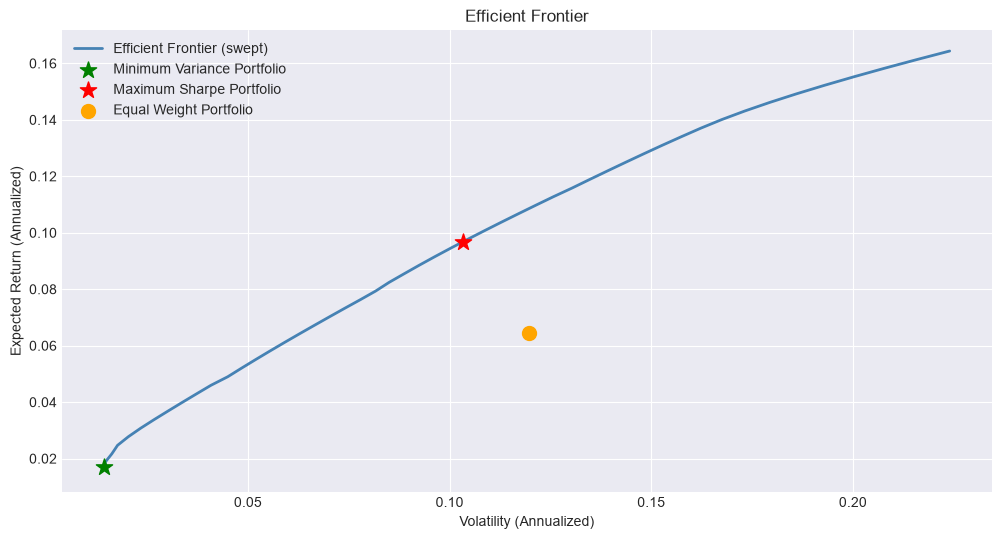

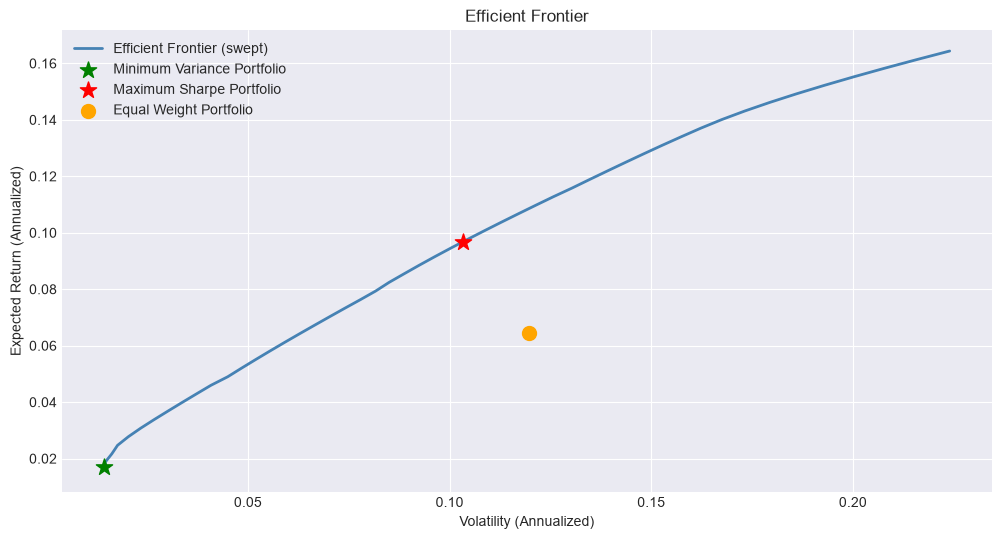

In [19]:
from src.utils.visualization import plot_efficient_frontier
from src.optimization.mean_variance import _portfolio_variance

min_var_return = min_var_weights @ annualized_returns
min_var_vol = np.sqrt(_portfolio_variance(min_var_weights.values, cov_matrix.values))

max_sharpe_return = max_sharpe_weights @ annualized_returns
max_sharpe_vol = np.sqrt(_portfolio_variance(max_sharpe_weights.values, cov_matrix.values))

plot_efficient_frontier(
    frontier,
    min_var_point=(min_var_vol, min_var_return),
    max_sharpe_point=(max_sharpe_vol, max_sharpe_return),
    equal_weight_point=(exp_vol, exp_return)
)

In [20]:
constrained_min_var = minimum_variance_portfolio(cov_matrix, max_weight=0.30)
print(constrained_min_var)

SPY   0.18429055036098915266
QQQ   0.00000000000000004543
VEA   0.00000000000000000000
VWO   0.00000000000000000000
IEF   0.29999999999999998890
TLT   0.12876512426623001883
SHY   0.29999999999999987788
VNQ   0.00000000000000000000
GLD   0.08694432537278094786
dtype: float64


In [21]:
asset_class_map = {
    "SPY": "Equity", "QQQ": "Equity", "VEA": "Equity", "VWO": "Equity",
    "IEF": "FixedIncome", "TLT": "FixedIncome", "SHY": "FixedIncome",
    "VNQ": "Alternatives", "GLD": "Alternatives"
}

asset_class_bounds = {
    "Equity": (0.40, 0.70),
    "FixedIncome": (0.20, 0.40),
    "Alternatives": (0.05, 0.20),
}

class_constrained_min_var = minimum_variance_portfolio(
    cov_matrix,
    max_weight=0.35,
    asset_class_map=asset_class_map,
    asset_class_bounds=asset_class_bounds,
)
print(class_constrained_min_var)
print("\nSum by asset class:")
for asset_class in set(asset_class_map.values()):
    tickers_in_class = [t for t, c in asset_class_map.items() if c == asset_class]
    print(f"{asset_class}: {class_constrained_min_var[tickers_in_class].sum():.2%}")

SPY   0.34999999999999997780
QQQ   0.01020308350023498532
VEA   0.03979691649976502266
VWO   0.00000000000000000795
IEF   0.10173732967380676173
TLT   0.06887248043925714436
SHY   0.22939018988693612999
VNQ   0.00000000000000000000
GLD   0.19999999999999998335
dtype: float64

Sum by asset class:
Equity: 40.00%
Alternatives: 20.00%
FixedIncome: 40.00%


In [22]:
class_constrained_max_sharpe = maximum_sharpe_portfolio(
    annualized_returns,
    cov_matrix,
    risk_free_rate=0.02,
    max_weight=0.35,
    asset_class_map=asset_class_map,
    asset_class_bounds=asset_class_bounds,
)
print(class_constrained_max_sharpe)
print("\nSum by asset class:")
for asset_class in set(asset_class_map.values()):
    tickers_in_class = [t for t, c in asset_class_map.items() if c == asset_class]
    print(f"{asset_class}: {class_constrained_max_sharpe[tickers_in_class].sum():.2%}")

SPY   0.05000000000000068279
QQQ   0.34999999999999870104
VEA   0.00000000000000130949
VWO   0.00000000000000144455
IEF   0.34999999999999559241
TLT   0.00014975670372581115
SHY   0.04985024329627857353
VNQ   0.00000000000000000000
GLD   0.19999999999999859557
dtype: float64

Sum by asset class:
Equity: 40.00%
Alternatives: 20.00%
FixedIncome: 40.00%


In [23]:
import sys
sys.path.append("..")
from src.optimization.advanced_optimization import risk_parity_portfolio, max_diversification_portfolio

rp_weights = risk_parity_portfolio(cov_matrix)
print("Risk Parity weights:\n", rp_weights)

# Verify: check that risk contributions are actually roughly equal
from src.optimization.advanced_optimization import _risk_contributions
rc = _risk_contributions(rp_weights.values, cov_matrix.values)
print("\nRisk contributions (should be roughly equal):\n", pd.Series(rc, index=TICKERS))

max_div_weights = max_diversification_portfolio(cov_matrix)
print("\nMaximum Diversification weights:\n", max_div_weights)

Risk Parity weights:
 SPY   0.03509976125417794274
QQQ   0.03183572013452221072
VEA   0.03097410522018494844
VWO   0.02697447500065831491
IEF   0.12424512048185372415
TLT   0.06679367708259359437
SHY   0.61109607553801881252
VNQ   0.02437102916189774066
GLD   0.04861003612609265251
dtype: float64

Risk contributions (should be roughly equal):
 SPY   0.00425473288251809224
QQQ   0.00425486240732705738
VEA   0.00425497090571175934
VWO   0.00425497863792054492
IEF   0.00425483818851333552
TLT   0.00425492207479515137
SHY   0.00425489101869991164
VNQ   0.00425492024597756615
GLD   0.00425489511031362788
dtype: float64

Maximum Diversification weights:
 SPY   0.03834329787112027155
QQQ   0.03117788852402141736
VEA   0.00000000000000001058
VWO   0.02939355730760152483
IEF   0.00000000000000000000
TLT   0.11410274690321287050
SHY   0.71133834962942144031
VNQ   0.02132985447782619753
GLD   0.05431430528679655201
dtype: float64


In [24]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
from src.portfolio.portfolio_theory import portfolio_expected_return, portfolio_volatility, sharpe_ratio
from src.risk.risk_engine import maximum_drawdown, herfindahl_index
from src.features.return_calculator import calculate_cumulative_returns

def evaluate_portfolio(weights, simple_returns, annualized_returns, cov_matrix, risk_free_rate=0.02):
    """
    Compute the full comparison metric set for a given weight vector.
    """
    w = weights.values if isinstance(weights, pd.Series) else weights
    
    exp_ret = portfolio_expected_return(w, annualized_returns)
    exp_vol = portfolio_volatility(w, cov_matrix)
    sharpe = sharpe_ratio(exp_ret, exp_vol, risk_free_rate)
    
    port_returns = simple_returns.dot(w)
    port_cumulative = calculate_cumulative_returns(port_returns)
    mdd = maximum_drawdown(port_cumulative)["max_drawdown"]
    
    hhi = herfindahl_index(w)
    
    equal_w = np.array([1/len(w)] * len(w))
    turnover = np.sum(np.abs(w - equal_w)) / 2  # proxy: distance from equal-weight
    
    return {
        "Expected Return": exp_ret,
        "Volatility": exp_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": mdd,
        "HHI (Concentration)": hhi,
        "Turnover (vs Equal-Weight)": turnover,
    }

strategies = {
    "Equal Weight": eq_weights,
    "Custom Allocation": custom_weights,
    "Inverse Volatility": inv_vol_weights,
    "Minimum Variance": min_var_weights,
    "Maximum Sharpe": max_sharpe_weights,
    "Risk Parity": rp_weights,
    "Max Diversification": max_div_weights,
}

comparison = pd.DataFrame({
    name: evaluate_portfolio(w, simple_returns, annualized_returns, cov_matrix)
    for name, w in strategies.items()
}).T

comparison

,Expected Return,Volatility,Sharpe Ratio,Max Drawdown,HHI (Concentration),Turnover (vs Equal-Weight)
Equal Weight,0.06443231019258990888,0.11968536869844637049,0.37124262285174947085,-0.33865451119028611160,0.11111111111111110494,0.00000000000000000000
Custom Allocation,0.07448597601642854837,0.12890692975732201409,0.42267685778416191900,-0.35507866008914257261,0.12839999999999998637,0.17555555555555554803
Inverse Volatility,0.03435640553124469365,0.04334223860928686917,0.33123359549242503697,-0.13175924183669621148,0.36849384003293661483,0.48613281640130967531
Minimum Variance,0.01696450457956577909,0.01436379850490186044,-0.21132957409548130956,-0.05993806224212248901,0.96072991370729154958,0.86896743003179155451
Maximum Sharpe,0.09672842504315540269,0.10321261299279846368,0.74340163298170769401,-0.23651936876443804825,0.35546323252742567655,0.66666666666666063445
Risk Parity,0.03177467654161359595,0.03829401147177703690,0.30748088510632054504,-0.12723466528554222554,0.40022606528665838344,0.51311897379765025740
Max Diversification,0.03008215303183855993,0.03459432539482459185,0.29143950392936057714,-0.12030806311858378843,0.52573294139084525423,0.60321887431041187888


## Results & Interpretation — Full Strategy Comparison (Modules 11–14)

### Reading the table as one coherent story

**Sharpe Ratio ranking:** Maximum Sharpe (0.743) > Custom Allocation (0.423) >
Equal Weight (0.371) > Inverse Volatility (0.331) > Risk Parity (0.307) >
Max Diversification (0.291) > **Minimum Variance (-0.211)**.

**Minimum Variance's negative Sharpe ratio** is the single most important number
in this table. It is not an error — it is the direct, honest consequence of an
objective that minimizes risk with *zero* regard for return. Its expected return
(1.70%) falls below the assumed 2% risk-free rate, producing negative excess
return. This proves that "lowest risk" and "good portfolio" are not the same
thing: pushed to its logical extreme, the safest portfolio by volatility can
still underperform a risk-free investment entirely.

**Maximum Drawdown pattern:** Minimum Variance has by far the shallowest drawdown
(-5.99%), consistent with being almost entirely one low-volatility asset that
barely moves. Custom Allocation has the deepest (-35.51%), consistent with its
meaningful growth-asset tilt (35% combined SPY/QQQ) carrying more crisis-period
pain.

**HHI (Concentration) — the most important row for judging realism:** Equal
Weight (0.111, the theoretical minimum for 9 assets) and Custom Allocation
(0.128) are the only genuinely well-diversified portfolios by this measure.
Every optimization-based method is meaningfully more concentrated — Minimum
Variance's HHI (0.961) sits near the maximum possible value of 1.0, confirming
it is, in practice, a single-asset position rather than a diversified portfolio.

**Turnover pattern** mirrors HHI closely: the more a strategy's weights diverge
from equal-weight, the higher its turnover proxy — Minimum Variance (0.869) is
the most different from equal-weight; Equal Weight is trivially 0 by definition.

### Honest synthesis — no universal "best" strategy

- **Priority: risk-adjusted return** → Maximum Sharpe wins clearly, but uses only
  3 of 9 assets and is the method most exposed to return-estimation error.
- **Priority: capital preservation** → Minimum Variance wins decisively on
  drawdown, but at the cost of a negative Sharpe ratio and near-total
  concentration in one asset.
- **Priority: genuine diversification** → Only Equal Weight and Custom
  Allocation remain real contenders by HHI; every optimizer here trades
  diversification for a narrower objective.
- **Sophistication ≠ better outcome:** Risk Parity's Sharpe (0.307) is *lower*
  than Equal Weight's (0.371), despite being the mathematically more
  sophisticated method. Portfolio outcomes are driven by the objective being
  optimized and the characteristics of the underlying data — not by how
  advanced the methodology sounds.

In [25]:
import sys
sys.path.append("..")
from src.portfolio.benchmarks import sixty_forty_benchmark, equal_weight_multiasset_benchmark

benchmark_6040 = sixty_forty_benchmark(TICKERS)
benchmark_ew = equal_weight_multiasset_benchmark(TICKERS)

all_portfolios = {
    "60/40 Benchmark": benchmark_6040,
    "Equal-Weight Benchmark": benchmark_ew,
    "Custom Allocation": custom_weights,
    "Inverse Volatility": inv_vol_weights,
    "Minimum Variance": min_var_weights,
    "Maximum Sharpe": max_sharpe_weights,
    "Risk Parity": rp_weights,
    "Max Diversification": max_div_weights,
}

full_comparison = pd.DataFrame({
    name: evaluate_portfolio(w, simple_returns, annualized_returns, cov_matrix)
    for name, w in all_portfolios.items()
}).T

full_comparison

,Expected Return,Volatility,Sharpe Ratio,Max Drawdown,HHI (Concentration),Turnover (vs Equal-Weight)
60/40 Benchmark,0.07874741589804816477,0.11363761246364853519,0.51697157855055109188,-0.30790297469961008803,0.52000000000000001776,0.77777777777777779011
Equal-Weight Benchmark,0.06443231019258990888,0.11968536869844637049,0.37124262285174947085,-0.33865451119028611160,0.11111111111111110494,0.00000000000000000000
Custom Allocation,0.07448597601642854837,0.12890692975732201409,0.42267685778416191900,-0.35507866008914257261,0.12839999999999998637,0.17555555555555554803
Inverse Volatility,0.03435640553124469365,0.04334223860928686917,0.33123359549242503697,-0.13175924183669621148,0.36849384003293661483,0.48613281640130967531
Minimum Variance,0.01696450457956577909,0.01436379850490186044,-0.21132957409548130956,-0.05993806224212248901,0.96072991370729154958,0.86896743003179155451
Maximum Sharpe,0.09672842504315540269,0.10321261299279846368,0.74340163298170769401,-0.23651936876443804825,0.35546323252742567655,0.66666666666666063445
Risk Parity,0.03177467654161359595,0.03829401147177703690,0.30748088510632054504,-0.12723466528554222554,0.40022606528665838344,0.51311897379765025740
Max Diversification,0.03008215303183855993,0.03459432539482459185,0.29143950392936057714,-0.12030806311858378843,0.52573294139084525423,0.60321887431041187888


## Results & Interpretation — Module 15

### Reading the comparison against both benchmarks

**Against the 60/40 Benchmark (Return 7.87%, Volatility 11.36%, Sharpe 0.517):**
This benchmark turned out to be a considerably tougher standard than SPY alone. Only
**Maximum Sharpe** (Sharpe 0.743, Return 9.67%) clearly outperforms it on a
risk-adjusted basis. Every other constructed strategy — Custom Allocation (0.423),
Inverse Volatility (0.331), Risk Parity (0.307), Max Diversification (0.291), and
especially Minimum Variance (**-0.211**) — falls short of 60/40's Sharpe ratio.
Minimum Variance in particular is dominated outright: 60/40 achieves both higher
return *and* higher Sharpe, with only moderately more volatility.

**Against the Equal-Weight Multi-Asset Benchmark (Return 6.44%, Sharpe 0.371):**
The picture is slightly kinder to our methods. Maximum Sharpe (0.743) and Custom
Allocation (0.423) both edge past this more modest baseline, but Inverse Volatility,
Minimum Variance, Risk Parity, and Max Diversification still fall short.

### Honest synthesis

Across six constructed strategies, only **one** — Maximum Sharpe — clearly and
consistently beat both benchmarks on a risk-adjusted basis, and its margin over
60/40 specifically was meaningful but not dramatic (0.743 vs 0.517 Sharpe). The
60/40 benchmark required no covariance matrix, no solver, no historical return
assumptions — just two ETFs held at two fixed weights — and it still outperformed
four of our six purpose-built optimization methods.

This is not a failure of the analysis; it is the honest result, and it matches a
well-documented pattern in real quantitative finance: naive, low-cost benchmarks
are genuinely difficult to beat consistently, and much of the value of building
optimization infrastructure lies not in guaranteed outperformance, but in
**understanding precisely why and when each method succeeds or fails**, and being
able to select or blend methods deliberately based on an investor's actual
objective (Module 11–14), rather than assuming mathematical sophistication alone
guarantees a better outcome.

### A note on volatility vs. drawdown

Maximum Sharpe does not just win on Sharpe ratio — it strictly dominates the
60/40 benchmark on every metric in this table: higher return (9.67% vs 7.87%),
lower volatility (10.32% vs 11.36%), higher Sharpe (0.743 vs 0.517), and a
shallower maximum drawdown (-23.65% vs -30.79%). Volatility and maximum
drawdown agree here rather than diverge, so this is a case of clear, one-sided
outperformance rather than a risk/reward tradeoff.

In [26]:
import sys
sys.path.append("..")
import pandas as pd
import numpy as np

# Train: 2008-01-02 through end of 2018. Test: 2019 onward.
split_date = "2019-01-01"

train_returns = simple_returns[simple_returns.index < split_date]
test_returns = simple_returns[simple_returns.index >= split_date]

print(f"Train period: {train_returns.index.min().date()} to {train_returns.index.max().date()} ({len(train_returns)} days)")
print(f"Test period: {test_returns.index.min().date()} to {test_returns.index.max().date()} ({len(test_returns)} days)")

Train period: 2008-01-03 to 2018-12-31 (2768 days)
Test period: 2019-01-02 to 2026-09-25 (1944 days)


Why 2019 as the split, worth being explicit about: this gives us roughly 11 years of training data (2008–2018, including the full 2008 crisis) and about 7-8 years of out-of-sample testing (2019–2026) — which conveniently captures COVID (2020) and the 2022 rate-hiking bear market as genuine, unseen stress events the strategy's inputs never had access to. This isn't cherry-picked for a favorable result — it's chosen for a reasonable, defensible split ratio (roughly 60/40 train/test by time), consistent with how we'd justify any such choice.

## Portfolio backtesting module.

Implements train/test split and walk-forward backtesting with rebalancing
and transaction cost modeling.

Why compute_inputs and get_strategy_weights are separated from anything we've built before, rather than reusing Modules 8/12 directly: the math is identical to what we've already built but the critical new discipline is that these functions are always called with a train_window that excludes the test period entirely. This function signature makes that discipline explicit and enforceable in the code itself, rather than something we just have to remember to do correctly by hand each time.

In [27]:
from src.backtesting.backtest_engine import backtest_single_split

strategies_to_test = ["Equal Weight", "Minimum Variance", "Maximum Sharpe"]
single_split_results = {}

for strat in strategies_to_test:
    result = backtest_single_split(strat, train_returns, test_returns)
    single_split_results[strat] = result
    print(f"{strat}: out-of-sample cumulative return = {result['cumulative_return']:.2%}")

Equal Weight: out-of-sample cumulative return = 111.02%
Minimum Variance: out-of-sample cumulative return = 19.05%
Maximum Sharpe: out-of-sample cumulative return = 68.72%


## Results & Interpretation — Single Train/Test Split (2008–2018 train, 2019–2026 test)

Weights for each strategy were computed **once**, using only 2008–2018 data,
then held completely fixed and applied to the 2019–2026 test period — data
none of the strategies had access to when their weights were built.

| Strategy | Out-of-Sample Cumulative Return |
|---|---|
| Equal Weight | **111.02%** |
| Maximum Sharpe | 68.72% |
| Minimum Variance | 19.05% |

**The key finding:** Maximum Sharpe was the standout performer in every
in-sample comparison (Modules 12–15), but here — tested on data it never saw —
it is clearly outperformed by simple Equal Weighting. This is a direct,
concrete demonstration of the estimation-risk concern raised as far back as
Module 12: Maximum Sharpe's 2008–2018 weights were heavily concentrated in
that period's best-performing assets (QQQ, IEF, GLD), and that specific bet
did not repeat itself as strongly afterward. Equal Weight, having made no such
bet, automatically captured whatever *did* perform well after 2019 without
needing to predict it in advance.

Minimum Variance remained weak, consistent with its design — it was never
built to chase return, only to minimize risk, so this result confirms rather
than surprises.

**Caveat:** this is a single, static split, reflecting one specific realized
path of history. A different split date could tell a different story — which
is exactly why the walk-forward test below exists.

In [28]:
from src.backtesting.backtest_engine import walk_forward_backtest
from src.features.return_calculator import calculate_cumulative_returns
from src.risk.risk_engine import maximum_drawdown

walk_forward_results = {}

for strat in strategies_to_test:
    result = walk_forward_backtest(strat, simple_returns, initial_train_years=10)
    oos_ret = result["oos_returns"]
    oos_cumulative = calculate_cumulative_returns(oos_ret)
    
    total_return = oos_cumulative.iloc[-1]
    n_years = (oos_ret.index[-1] - oos_ret.index[0]).days / 365.25
    annualized = (1 + total_return) ** (1/n_years) - 1
    vol = oos_ret.std() * np.sqrt(252)
    sharpe = (annualized - 0.02) / vol
    mdd = maximum_drawdown(oos_cumulative)["max_drawdown"]
    
    walk_forward_results[strat] = {
        "Total Return": total_return, "Annualized Return": annualized,
        "Volatility": vol, "Sharpe": sharpe, "Max Drawdown": mdd
    }
    print(f"{strat}: Annualized {annualized:.2%}, Sharpe {sharpe:.3f}, Max DD {mdd:.2%}")

Equal Weight: Annualized 10.04%, Sharpe 0.719, Max DD -23.23%
Minimum Variance: Annualized 2.26%, Sharpe 0.148, Max DD -6.01%
Maximum Sharpe: Annualized 9.65%, Sharpe 0.808, Max DD -22.55%


## Results & Interpretation — Walk-Forward Backtest (expanding window, annual rebalancing, 10-year initial training period)

Rather than freezing weights once, this test re-estimates each strategy's
weights every year using an expanding history, then evaluates that year's
performance out-of-sample, before moving forward and repeating — stitching
the results into one continuous track record from roughly 2018 onward.

| Strategy | Annualized Return | Sharpe Ratio | Max Drawdown |
|---|---|---|---|
| Equal Weight | 10.04% | 0.719 | -23.23% |
| Maximum Sharpe | 9.65% | **0.808** | **-22.55%** |
| Minimum Variance | 2.26% | 0.148 | -6.01% |

**The key finding — this reverses part of the single-split conclusion.**
Under walk-forward testing, Maximum Sharpe's Sharpe ratio (0.808) actually
edges out Equal Weight's (0.719), with a comparable annualized return and a
slightly shallower drawdown. This is a materially different outcome from the
static single-split test, and the reason why is itself the lesson: the
single-split test evaluated one frozen 2008–2018 estimate applied blindly for
eight years, while the walk-forward test allows Maximum Sharpe to
**re-optimize annually** as new data arrives — so it is never stuck betting
indefinitely on one historical snapshot.

**The honest, complete conclusion:** a single frozen estimate of Maximum
Sharpe weights does not reliably generalize (single-split result), but the
*method* of periodically re-deriving Maximum Sharpe weights on an expanding
window performs competitively, and even favorably, over time (walk-forward
result). This distinguishes a genuine weakness in the *static application* of
an optimization from a weakness in the *optimization method itself* —
a distinction that only emerges by testing both ways rather than relying on
a single backtest design.

In [29]:
import sys
sys.path.append("..")
from src.backtesting.rebalancing_engine import (
    compute_drifted_weights, calendar_rebalance_dates,
    detect_threshold_breaches, compute_rebalancing_trades
)

drifted = compute_drifted_weights(max_sharpe_weights, prices, start_date="2019-01-01")
drifted.tail()

,SPY,QQQ,VEA,VWO,IEF,TLT,SHY,VNQ,GLD
Date,,,,,,,,,
2026-09-21,0.00000000000000000000,0.65714618480002440215,0.00000000000000000000,0.00000000000000030693,0.12109608865294702040,0.00000000000000152805,0.00000000000000000000,0.00000000000000006940,0.22175772654702682884
2026-09-22,0.00000000000000000000,0.65833197708166002471,0.00000000000000000000,0.00000000000000030482,0.12035560681568673036,0.00000000000000151761,0.00000000000000000000,0.00000000000000006883,0.22131241610265156572
2026-09-23,0.00000000000000000000,0.65992992824279117503,0.00000000000000000000,0.00000000000000030319,0.12037046877904984676,0.00000000000000150991,0.00000000000000000000,0.00000000000000006856,0.21969960297815716022
2026-09-24,0.00000000000000000000,0.66077735500170942107,0.00000000000000000000,0.00000000000000030236,0.11987466313403985496,0.00000000000000149253,0.00000000000000000000,0.00000000000000006845,0.21934798186424891986
2026-09-25,0.00000000000000000000,0.66089495393827468739,0.00000000000000000000,0.00000000000000030250,0.11976095623606365648,0.00000000000000148411,0.00000000000000000000,0.00000000000000006801,0.21934408982565981039


In [30]:
breaches = detect_threshold_breaches(drifted, max_sharpe_weights, threshold=0.05)
breaches.head(20)

,date,ticker,target_weight,actual_weight,drift
0,2019-12-16,QQQ,0.41771236297482466915,0.46883836802665923571,0.05112600505183456656
1,2019-12-17,QQQ,0.41771236297482466915,0.46898789315756489460,0.05127553018274022545
2,2019-12-18,QQQ,0.41771236297482466915,0.46958769755068752172,0.05187533457586285257
3,2019-12-19,QQQ,0.41771236297482466915,0.47077268074150835364,0.05306031776668368449
4,2019-12-20,QQQ,0.41771236297482466915,0.47167889196508128169,0.05396652899025661254
5,2019-12-23,QQQ,0.41771236297482466915,0.47217942964817344320,0.05446706667334877405
6,2019-12-24,QQQ,0.41771236297482466915,0.47114039093712184458,0.05342802796229717543
7,2019-12-26,QQQ,0.41771236297482466915,0.47235114596310739943,0.05463878298828273028
8,2019-12-27,QQQ,0.41771236297482466915,0.47195497559356025530,0.05424261261873558615
9,2019-12-30,QQQ,0.41771236297482466915,0.47020863811166235813,0.05249627513683768898


## Results & Interpretation — Portfolio Drift (Maximum Sharpe, 2019–2026)

The Maximum Sharpe portfolio was formed on 2019-01-01 with target weights of
roughly 42% QQQ, 36% IEF, and 22% GLD, and never rebalanced. Tracking its
actual weights forward through real price movements reveals dramatic passive
drift:

- **QQQ drifted from ~42% to ~66%** by 2026 — a 24 percentage point increase,
  driven entirely by QQQ's strong outperformance over the period, with zero
  deliberate trading involved.
- **IEF drifted from ~36% to ~12%** — an equally large decrease, reflecting
  bonds' weak relative performance over the same stretch, especially through
  the 2022 rate-hiking cycle.
- **GLD stayed comparatively close to its original 22% target.**

### Threshold breach timing

Using a 5-percentage-point drift threshold, the **first breach occurred on
2019-12-16** — less than one year after the portfolio was formed. This means
an investor on a rigid **annual** calendar-based rebalancing schedule would
have carried a meaningfully drifted portfolio for nearly a full year before
any scheduled correction, while a **threshold-based** approach would have
flagged the need to act by mid-December of the very first year.

### The core lesson

A portfolio that looked carefully optimized and diversified at formation (42%
QQQ / 36% IEF / 22% GLD) silently transformed, through drift alone, into a
far more concentrated, equity-heavy position (66% QQQ) without a single
deliberate decision being made. This is precisely the risk unmonitored drift
poses: the portfolio's *actual* risk profile can diverge substantially from
its *intended* one, well before a fixed calendar date would have caught it.
This result also suggests that **more concentrated portfolios likely require
more responsive (threshold-based) monitoring**, a hypothesis to be tested
directly against a more diversified strategy such as Equal Weight.

In [31]:
drifted_eq = compute_drifted_weights(eq_weights, prices, start_date="2019-01-01")
breaches_eq = detect_threshold_breaches(drifted_eq, eq_weights, threshold=0.05)
print(f"Maximum Sharpe: first breach on {breaches['date'].min().date()}")
print(f"Equal Weight: first breach on {breaches_eq['date'].min().date() if len(breaches_eq) > 0 else 'No breaches found'}")

Maximum Sharpe: first breach on 2019-12-16
Equal Weight: first breach on 2020-09-02


In [32]:
import sys
sys.path.append("..")
from src.backtesting.stress_testing import (
    HISTORICAL_SCENARIOS, HYPOTHETICAL_SCENARIOS,
    run_historical_scenario, run_hypothetical_scenario
)

strategies_stress = {
    "Equal Weight": eq_weights,
    "Minimum Variance": min_var_weights,
    "Maximum Sharpe": max_sharpe_weights,
}

print("=== HISTORICAL SCENARIOS ===")
for scenario_name, (start, end) in HISTORICAL_SCENARIOS.items():
    print(f"\n--- {scenario_name} ---")
    for strat_name, w in strategies_stress.items():
        result = run_historical_scenario(w, simple_returns, start, end)
        print(f"{strat_name}: Return {result['total_return']:.2%}, Max DD {result['max_drawdown']:.2%}")

print("\n=== HYPOTHETICAL SCENARIOS ===")
for scenario_name, shock in HYPOTHETICAL_SCENARIOS.items():
    print(f"\n--- {scenario_name} ---")
    for strat_name, w in strategies_stress.items():
        result = run_hypothetical_scenario(w, shock, TICKERS)
        print(f"{strat_name}: Instantaneous Return {result['portfolio_return']:.2%}")

=== HISTORICAL SCENARIOS ===

--- 2008 Global Financial Crisis ---
Equal Weight: Return -18.64%, Max DD -28.24%
Minimum Variance: Return 2.76%, Max DD -1.07%
Maximum Sharpe: Return -8.24%, Max DD -19.73%

--- 2020 COVID Crash ---
Equal Weight: Return -8.26%, Max DD -18.00%
Minimum Variance: Return 1.73%, Max DD -0.89%
Maximum Sharpe: Return -2.37%, Max DD -11.85%

--- 2022 Rate-Hike Bear Market ---
Equal Weight: Return -20.90%, Max DD -22.87%
Minimum Variance: Return -5.00%, Max DD -5.31%
Maximum Sharpe: Return -20.46%, Max DD -22.31%

=== HYPOTHETICAL SCENARIOS ===

--- Equity Crash ---
Equal Weight: Instantaneous Return -13.33%
Minimum Variance: Instantaneous Return -0.60%
Maximum Sharpe: Instantaneous Return -12.53%

--- Inflation/Rate Shock ---
Equal Weight: Instantaneous Return -6.11%
Minimum Variance: Instantaneous Return -14.80%
Maximum Sharpe: Instantaneous Return -5.44%

--- Simultaneous Equity & Bond Crash ---
Equal Weight: Instantaneous Return -13.89%
Minimum Variance: Insta

## Results & Interpretation — Module 18: Stress Testing

### Historical Scenarios

| Scenario | Equal Weight | Minimum Variance | Maximum Sharpe |
|---|---|---|---|
| 2008 Global Financial Crisis | -18.64% (DD -28.24%) | **+2.76%** (DD -1.07%) | -8.24% (DD -19.73%) |
| 2020 COVID Crash | -8.26% (DD -18.00%) | **+1.73%** (DD -0.89%) | -2.37% (DD -11.85%) |
| 2022 Rate-Hike Bear Market | -20.90% (DD -22.87%) | **-5.00%** (DD -5.31%) | -20.46% (DD -22.31%) |

In 2008 and 2020 — both growth-driven, flight-to-safety crises — Minimum
Variance was essentially untouched or even slightly positive, while Equal
Weight and Maximum Sharpe both took real losses. This matches the classic
stock/bond diversification story we've relied on throughout the project.

**2022 breaks that pattern.** Minimum Variance posted a real loss (-5.00%)
for the first time, and Equal Weight and Maximum Sharpe converged to nearly
identical losses (-20.90% vs -20.46%) — the usual gap between them nearly
vanished. This is direct, concrete evidence of a simultaneous equity-and-bond
decline: because rate hikes hurt both asset classes through different
mechanisms at once, there was no genuinely safe corner of this asset universe
in 2022 except cash-like exposure, and even that only helped partially.

### Hypothetical Scenarios

| Scenario | Equal Weight | Minimum Variance | Maximum Sharpe |
|---|---|---|---|
| Equity Crash | -13.33% | **-0.60%** | -12.53% |
| Inflation/Rate Shock | -6.11% | **-14.80%** | -5.44% |
| Simultaneous Equity & Bond Crash | -13.89% | -10.30% | -13.03% |

The Equity Crash scenario behaves exactly as intuition predicts — Minimum
Variance is barely touched, since it holds almost no equity exposure.

**The Inflation/Rate Shock scenario reverses the ranking entirely.**
Minimum Variance is the *worst* performer of the three (-14.80%), because its
entire risk-reduction strategy is built on ~96% concentration in bonds and
cash-like assets — precisely the asset class this scenario targets directly.
The portfolio that looked "safest" under every prior test becomes the most
exposed portfolio under this one.

### Core lesson

There is no universally "safe" portfolio — safety is always conditional on
*which* economic force is driving the crisis. Minimum Variance protects
effectively against growth-driven, flight-to-safety shocks, but is maximally
exposed to inflation/rate-driven shocks, since it concentrates precisely in
the asset class that type of shock damages most. Presenting only the
flattering 2008/2020 results while omitting 2022 and the inflation shock
would create a materially false impression of "crisis-proof" safety, when the
truth is a specific, characterizable vulnerability to a different type of
crisis — exactly the kind of selective reporting the project's methodology is
designed to avoid.

### Factor analysis module.
Provides a simplified, honest factor exposure analysis covering Market,
Momentum, and Volatility factors, using data already computed elsewhere in
this project. Value, Quality, and Size factors are explicitly out of scope
(see module docstring notes) since they require external fundamental data
not available for our ETF universe.

In [33]:
import sys
sys.path.append("..")
from src.portfolio.factor_analysis import (
    market_factor_exposure, calculate_momentum_scores,
    portfolio_momentum_exposure, portfolio_volatility_factor_exposure
)

momentum_scores = calculate_momentum_scores(prices, lookback_days=252)
print("Trailing 12-month momentum by asset:\n", momentum_scores)

individual_vols = np.sqrt(np.diag(cov_matrix))
individual_vols_series = pd.Series(individual_vols, index=TICKERS)

factor_summary = {}
for strat_name, w in strategies_stress.items():
    port_returns = simple_returns.dot(w.values)
    factor_summary[strat_name] = {
        "Market (Beta)": market_factor_exposure(port_returns, simple_returns["SPY"]),
        "Momentum": portfolio_momentum_exposure(w, momentum_scores),
        "Volatility Factor": portfolio_volatility_factor_exposure(w, individual_vols_series),
    }

pd.DataFrame(factor_summary).T

Trailing 12-month momentum by asset:
 SPY    0.18482151688266390543
QQQ    0.26025300343426738259
VEA    0.24867757002684354184
VWO    0.14692738458078946628
IEF   -0.02812081756133011368
TLT   -0.06772174384635953892
SHY    0.01615657680130477836
VNQ    0.04772766026830099761
GLD    0.14114576841801129703
dtype: float64


,Market (Beta),Momentum,Volatility Factor
Equal Weight,0.54513959508535358989,0.10554076877827685277,0.17894985350056905049
Minimum Variance,0.00513714685686424144,0.01930578991103003988,0.01913015652411649906
Maximum Sharpe,0.41220163605924819983,0.12880997751218425940,0.15832307025477232454


## Results & Interpretation — Module 19: Factor Exposure Analysis

### Trailing 12-month momentum by asset
QQQ (+26.0%) and VEA (+24.9%) show the strongest recent momentum, while TLT
(-6.8%) and IEF (-2.8%) are actual laggards — consistent with the difficult
recent environment for fixed income already observed throughout this project.

### Factor exposure comparison

| Strategy | Market (Beta) | Momentum | Volatility Factor |
|---|---|---|---|
| Equal Weight | 0.545 | 0.106 | 0.179 |
| Minimum Variance | 0.005 | 0.019 | 0.019 |
| Maximum Sharpe | 0.412 | **0.129** | 0.158 |

**Maximum Sharpe shows the highest momentum exposure of the three strategies**,
despite never being explicitly told to target momentum — its objective is
purely historical risk-adjusted return. This happens because assets with
strong recent performance mechanically contribute to both a high historical
average return *and* strong trailing momentum; they are not independent
signals. As a result, Maximum Sharpe's optimizer implicitly absorbed a
momentum-like tilt as a side effect of chasing return, without momentum ever
appearing in its objective function.

**Minimum Variance is confirmed as effectively market-neutral and low-volatility-
factor-tilted by design** (Beta 0.005, Volatility Factor 0.019) — both numbers
directly reflect its near-total concentration in low-beta, low-volatility
assets like SHY.

### The core lesson

Optimizers can implicitly acquire factor exposures that were never explicitly
specified, simply because their inputs are correlated with those factors in
the underlying data. This is not necessarily a flaw — the optimizer is
detecting a real pattern — but it is a risk worth naming explicitly: an
investor holding a "return-optimized" portfolio may not realize they are also
making an implicit momentum bet, which carries its own well-documented risk of
sharp reversals ("momentum crashes") that a purely historical, backward-looking
optimization process cannot anticipate.

### Scope note
Value, Quality, and Size factors are explicitly out of scope for this project.
Rigorous treatment of these factors requires external fundamental data
(price-to-earnings ratios, company financials, market-capitalization
breakdowns) that is not readily available or well-defined for a 9-ETF
multi-asset universe. Rather than force a low-quality approximation, this
project limits factor analysis to Market, Momentum, and Volatility, where a
simplified but honest treatment is possible using data already computed
elsewhere in the pipeline.

In [34]:
import sys
sys.path.append("..")
from src.forecasting.volatility_forecasting import build_volatility_features, walk_forward_volatility_forecast
from sklearn.metrics import mean_absolute_error

spy_features = build_volatility_features(simple_returns["SPY"], target_horizon=21)
print(spy_features.shape)
spy_features.head()

(4632, 5)


,trailing_vol_21d,trailing_vol_60d,trailing_mean_abs_return_21d,trailing_return_21d,target_volatility
Date,,,,,
2008-03-31,0.28172646974352499871,0.22980255266876431497,0.01363498641378852252,-0.03102727531338655975,0.17899597797577812552
2008-04-01,0.29776707041389971486,0.24169514468095779081,0.01424810512561528256,0.02590288914093696881,0.13616327804943709201
2008-04-02,0.29746715528554523722,0.23659258142695616112,0.01416562550528723159,0.02903923713848777233,0.15290426214687802275
2008-04-03,0.29683962786699663594,0.23666200687913044320,0.01410212519836329115,0.03555485686422654723,0.15292837707591169782
2008-04-04,0.29653819457231184176,0.23435755294571319896,0.01385346145954799088,0.02792833994876131598,0.15427843749534966844


In [35]:
# Manual verification: for 2008-03-31, target_volatility should equal the
# realized volatility of SPY's simple returns over the NEXT 21 trading days
# starting the day after 2008-03-31.
check_date = "2008-03-31"
check_idx = simple_returns.index.get_loc(check_date)
next_21_days_returns = simple_returns["SPY"].iloc[check_idx+1 : check_idx+22]
manual_target_vol = next_21_days_returns.std() * np.sqrt(252)

print(f"Manually computed forward 21-day vol: {manual_target_vol:.6f}")
print(f"Feature dataframe's target_volatility for this date: {spy_features.loc[check_date, 'target_volatility']:.6f}")

Manually computed forward 21-day vol: 0.178996
Feature dataframe's target_volatility for this date: 0.178996


In [36]:
linear_results = walk_forward_volatility_forecast(spy_features, model_type="linear", initial_train_years=5)

mae_model = mean_absolute_error(linear_results["actual"], linear_results["predicted"])
mae_baseline = mean_absolute_error(linear_results["actual"], linear_results["naive_baseline"])

print(f"Linear Regression MAE: {mae_model:.4f}")
print(f"Naive Baseline (current trailing vol) MAE: {mae_baseline:.4f}")
print(f"Model improvement over baseline: {(mae_baseline - mae_model) / mae_baseline:.2%}")

Linear Regression MAE: 0.0516
Naive Baseline (current trailing vol) MAE: 0.0567
Model improvement over baseline: 8.94%


In [37]:
rf_results = walk_forward_volatility_forecast(spy_features, model_type="random_forest", initial_train_years=5)

mae_rf = mean_absolute_error(rf_results["actual"], rf_results["predicted"])
print(f"Random Forest MAE: {mae_rf:.4f}")
print(f"Random Forest improvement over baseline: {(mae_baseline - mae_rf) / mae_baseline:.2%}")
print(f"Random Forest improvement over Linear Regression: {(mae_model - mae_rf) / mae_model:.2%}")

Random Forest MAE: 0.0543
Random Forest improvement over baseline: 4.19%
Random Forest improvement over Linear Regression: -5.21%


In [38]:
import sys
sys.path.append("..")

from src.forecasting.volatility_forecasting import (
    build_volatility_features, walk_forward_volatility_forecast,
    forecast_all_asset_volatilities, ml_inverse_volatility_portfolio,
    walk_forward_ml_vs_historical
)
from src.portfolio.construction import inverse_volatility_portfolio
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

test_date = "2019-01-01"
forecasted_vols = forecast_all_asset_volatilities(simple_returns, train_end_date=test_date)
print("ML-Forecasted Volatilities:\n", forecasted_vols)

historical_vols = simple_returns[simple_returns.index < test_date].tail(252).std() * np.sqrt(252)
print("\nHistorical (trailing 1yr) Volatilities:\n", historical_vols)

ml_weights = ml_inverse_volatility_portfolio(forecasted_vols)
hist_weights = inverse_volatility_portfolio(simple_returns[simple_returns.index < test_date])

print("\nML-Enhanced Inverse Vol Weights:\n", ml_weights)
print("\nHistorical Inverse Vol Weights:\n", hist_weights)

ML-Forecasted Volatilities:
 SPY   0.27471706504185755549
QQQ   0.32990948823167248749
VEA   0.21369157515090866917
VWO   0.22084168068715190336
IEF   0.04442673818677290304
TLT   0.10626342779637266978
SHY   0.00933278231777839515
VNQ   0.27789531504941683560
GLD   0.11998792502053251541
dtype: float64

Historical (trailing 1yr) Volatilities:
 SPY   0.17006724999674166510
QQQ   0.22854973754812191178
VEA   0.14276084256460269684
VWO   0.19923164054747175000
IEF   0.04037571931711832901
TLT   0.09253004318313018395
SHY   0.00825771982336890101
VNQ   0.16007486152042202376
GLD   0.09754651336150997609
dtype: float64

ML-Enhanced Inverse Vol Weights:
 SPY   0.02181268131478553488
QQQ   0.01816351455549305646
VEA   0.02804189068876245666
VWO   0.02713398925803352235
IEF   0.13488084059421970307
TLT   0.05639113960236655232
SHY   0.64207174103656572406
VNQ   0.02156321271708255827
GLD   0.04994099023269078785
dtype: float64

Historical Inverse Vol Weights:
 SPY   0.04002423267927410211
QQQ

In [39]:
comparison_results = walk_forward_ml_vs_historical(simple_returns, initial_train_years=10)

for name, result in comparison_results.items():
    oos_ret = result["oos_returns"]
    oos_cumulative = calculate_cumulative_returns(oos_ret)
    total_return = oos_cumulative.iloc[-1]
    n_years = (oos_ret.index[-1] - oos_ret.index[0]).days / 365.25
    annualized = (1 + total_return) ** (1/n_years) - 1
    vol = oos_ret.std() * np.sqrt(252)
    sharpe = (annualized - 0.02) / vol
    mdd = maximum_drawdown(oos_cumulative)["max_drawdown"]
    print(f"{name}: Annualized {annualized:.2%}, Vol {vol:.2%}, Sharpe {sharpe:.3f}, Max DD {mdd:.2%}")

ML-Enhanced: Annualized 4.88%, Vol 5.21%, Sharpe 0.553, Max DD -13.08%
Historical: Annualized 4.59%, Vol 4.40%, Sharpe 0.590, Max DD -12.42%


In [40]:
import sys
sys.path.append("..")
from src.portfolio.recommendation_engine import recommend_portfolio, RISK_PROFILES

asset_class_map = {
    "SPY": "Equity", "QQQ": "Equity", "VEA": "Equity", "VWO": "Equity",
    "IEF": "FixedIncome", "TLT": "FixedIncome", "SHY": "FixedIncome",
    "VNQ": "Alternatives", "GLD": "Alternatives"
}

for profile_name in ["Conservative", "Moderate", "Aggressive"]:
    result = recommend_portfolio(profile_name, annualized_returns, cov_matrix, TICKERS, asset_class_map)
    print(f"\n=== {profile_name} ===")
    print(result["weights"])
    print(f"HHI: {result['hhi']:.3f}")
    print(f"Recommended rebalancing: {result['recommended_rebalance_frequency']}")


=== Conservative ===
SPY   0.19743006462494330777
QQQ   0.00000000000000000000
VEA   0.00000000000000004510
VWO   0.00000000000000001951
IEF   0.29999999999999987788
TLT   0.09999999999999993616
SHY   0.29999999999999998890
VNQ   0.00000000000000000000
GLD   0.10256993537505677827
dtype: float64
HHI: 0.239
Recommended rebalancing: Semi-Annually

=== Moderate ===
SPY   0.00000000000000110589
QQQ   0.34999999999999997780
VEA   0.00000000000000000000
VWO   0.00000000000000000000
IEF   0.34999999999999997780
TLT   0.00000000000000000000
SHY   0.09014986382877418492
VNQ   0.00000000000000000000
GLD   0.20985013617123532415
dtype: float64
HHI: 0.297
Recommended rebalancing: Semi-Annually

=== Aggressive ===
SPY   0.09999999999999527323
QQQ   0.45000000000000001110
VEA   0.00000000000000000000
VWO   0.00000000000000000000
IEF   0.22076830798630003860
TLT   0.02923169201370619252
SHY   0.00000000000000000000
VNQ   0.00000000000000000000
GLD   0.20000000000000120459
dtype: float64
HHI: 0.302
R

In [41]:
moderate_with_hhi_cap = recommend_portfolio(
    "Moderate", annualized_returns, cov_matrix, TICKERS, asset_class_map,
    custom_overrides={"max_hhi": 0.15}
)
print(moderate_with_hhi_cap["weights"])
print(f"HHI: {moderate_with_hhi_cap['hhi']:.3f}")

SPY   0.14099087545315908132
QQQ   0.19868529451731437030
VEA   0.03905435436049500830
VWO   0.00000000000000036209
IEF   0.14837504824631786438
TLT   0.13125236431944353743
SHY   0.14074118255564249669
VNQ   0.03013157374101358907
GLD   0.17076930680661372985
dtype: float64
HHI: 0.150


In [42]:
import sys
sys.path.append("..")
from src.utils.model_persistence import save_model, load_model, save_walk_forward_models

saved_summary = save_walk_forward_models(simple_returns, initial_train_years=10)
print(f"Saved {len(saved_summary)} models.")

# Test loading one back
test_model, test_metadata = load_model("volatility_SPY_2019-01-01")
print(test_metadata)
print(test_model.coef_)

Saved 72 models.
{'model_name': 'volatility_SPY_2019-01-01', 'saved_timestamp': '2026-09-27T21:07:49.113261', 'feature_cols': ['trailing_vol_21d', 'trailing_vol_60d', 'trailing_mean_abs_return_21d', 'trailing_return_21d'], 'model_type': 'LinearRegression', 'ticker': 'SPY', 'train_end_date': '2019-01-01', 'train_rows': 2709, 'target_horizon_days': 21}
[ 8.35121178e-03  1.47233831e-01  1.06902436e+01 -5.03579402e-01]


we traded some disk space and a larger models/ folder (72 files instead of 9) in exchange for the ability to audit exactly what any specific historical rebalancing decision's model looked like its exact coefficients, exact training window, exact feature configuration without needing to rerun the walk-forward loop to reconstruct it.

In [44]:
from src.backtesting.backtest_engine import walk_forward_profile_backtest
from src.portfolio.benchmarks import sixty_forty_benchmark
from src.backtesting.backtest_engine import walk_forward_profile_backtest, compute_turnover_cost

profile_backtest_results = {}
for profile in ["Conservative", "Moderate", "Aggressive"]:
    result = walk_forward_profile_backtest(profile, simple_returns, TICKERS, asset_class_map, initial_train_years=10)
    profile_backtest_results[profile] = result

# 60/40 benchmark, walk-forward, SAME rebalance dates, for direct comparison
def walk_forward_6040(simple_returns, tickers, initial_train_years=10, cost_per_unit_turnover=0.001):
    start_date = simple_returns.index.min()
    first_rebalance = start_date + pd.DateOffset(years=initial_train_years)
    rebalance_dates = pd.date_range(start=first_rebalance, end=simple_returns.index.max(), freq="YS")
    weights = sixty_forty_benchmark(tickers)  # fixed weights, no re-estimation needed

    all_returns = []
    previous_weights = pd.Series(0.0, index=tickers)
    for i, rebal_date in enumerate(rebalance_dates):
        next_date = rebalance_dates[i+1] if i+1 < len(rebalance_dates) else simple_returns.index.max() + pd.Timedelta(days=1)
        test_window = simple_returns[(simple_returns.index >= rebal_date) & (simple_returns.index < next_date)]
        if len(test_window) == 0:
            continue
        cost = compute_turnover_cost(previous_weights, weights, cost_per_unit_turnover)
        period_returns = test_window.dot(weights.values)
        period_returns.iloc[0] -= cost
        all_returns.append(period_returns)
        previous_weights = weights
    return pd.concat(all_returns)

benchmark_6040_returns = walk_forward_6040(simple_returns, TICKERS)

for name, result in {**profile_backtest_results, "60/40 Benchmark": {"oos_returns": benchmark_6040_returns}}.items():
    oos_ret = result["oos_returns"] if isinstance(result, dict) else result
    cumulative = calculate_cumulative_returns(oos_ret)
    total_return = cumulative.iloc[-1]
    n_years = (oos_ret.index[-1] - oos_ret.index[0]).days / 365.25
    annualized = (1 + total_return) ** (1/n_years) - 1
    vol = oos_ret.std() * np.sqrt(252)
    sharpe = (annualized - 0.02) / vol
    mdd = maximum_drawdown(cumulative)["max_drawdown"]
    print(f"{name}: Annualized {annualized:.2%}, Sharpe {sharpe:.3f}, Max DD {mdd:.2%}")

Conservative: Annualized 6.13%, Sharpe 0.663, Max DD -16.55%
Moderate: Annualized 11.96%, Sharpe 0.880, Max DD -27.54%
Aggressive: Annualized 15.10%, Sharpe 0.943, Max DD -29.36%
60/40 Benchmark: Annualized 10.93%, Sharpe 0.766, Max DD -21.02%
